# Rekordy: najdłuższe struktury i sklejenia

Ten notatnik zbiera najdłuższe struktury kombinatoryczne wykraczające **poza pojedyncze słowo**:

- rekordy **przez granice słów** w korpusie Wolnych Lektur,
- **dwuwyrazowe** przetasowane kwadraty budowane ze słowników czterech języków,
- struktury w **sekwencjach kolejnych słów** realnego tekstu.

Najdłuższe struktury *wewnątrz pojedynczych słów* oraz ranking języków znajdują się w `dictionaries.ipynb`.

## 1. Przygotowanie środowiska

Importujemy funkcje rekordowe i generatywne z `natural_languages.analysis`, loadery danych oraz biblioteki wykresów. Przygotowujemy też katalog na rysunki.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "natural_languages").is_dir():
            return path
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from natural_languages.analysis import (  # noqa: E402
    longest_abelian_square,
    longest_palindrome,
    longest_square,
    phrase_abelian_squares,
    phrase_palindromes,
    phrase_shuffle_squares,
    split_sentences,
    two_word_shuffles,
)
from natural_languages.data import (  # noqa: E402
    DataLoader,
    TextPreprocessor,
    parse_wolne_lektury_file,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 100)

FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name: str) -> None:
    """Zapisuje bieżący wykres jako PNG 300 dpi do docs/figures."""
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=300, bbox_inches="tight")

## 2. Stałe i dane

Ustalamy języki, etykiety struktur, ścieżki do słowników i korpusu oraz limit długości dla przetasowanych kwadratów. `load_words` wczytuje i normalizuje listę słów (małe litery, bez duplikatów, długość >= `MIN_WORD_LENGTH`).

In [2]:
LANGUAGES = ["pl", "en", "de", "fr"]
LANGUAGE_LABELS = {"pl": "polski", "en": "angielski", "de": "niemiecki", "fr": "francuski"}

DICTIONARY_PATHS = {lang: PROJECT_ROOT / "data" / "raw" / f"{lang}.txt" for lang in LANGUAGES}
BOOKS_PATH = PROJECT_ROOT / "data" / "wolne_lektury_random_sample_25mb.txt"

MIN_WORD_LENGTH = 2
MAX_SHUFFLED_LEN = 40
CORPUS_MAX_LEN = 400  # limit długości zdania dla kosztownych kwadratów

STRUCTURE_LABELS = {
    "palindrome": "palindrom",
    "square": "kwadrat (ww)",
    "abelian_square": "kwadrat abelowy",
    "shuffled_square": "przetasowany kwadrat",
}

preprocessor = TextPreprocessor()


def load_words(language: str) -> list[str]:
    """Wczytuje i normalizuje listę słów danego języka (dedup, minimalna długość)."""
    raw = DataLoader(DICTIONARY_PATHS[language]).load_word_list()
    normalized = preprocessor.normalize_words(raw)
    return [w for w in dict.fromkeys(normalized) if len(w) >= MIN_WORD_LENGTH]

## 3. Rekordy przez granice słów (korpus)

W zdaniu usuwamy spacje i interpunkcję, a potem szukamy najdłuższego **podciągu** będącego
palindromem, kwadratem `ww` lub kwadratem abelowym — także *przez granice słów* (np. „kobyła
ma mały bok"). Szukamy tylko globalnego maksimum, więc finderom przekazujemy próg bieżącego
rekordu (krótsze trafienia są pomijane), a zdania deduplikujemy. Wynik: `corpus_records_df`.

In [4]:
corpus_best: dict[str, tuple[str, str]] = {}  # struktura -> (dopasowanie, zdanie)
seen_sentences: set[str] = set()

for book in parse_wolne_lektury_file(BOOKS_PATH):
    for sentence in split_sentences(book.text):
        normalized = preprocessor.normalize(sentence)
        if len(normalized) < 2 or normalized in seen_sentences:
            continue
        seen_sentences.add(normalized)

        floor = len(corpus_best["palindrome"][0]) + 1 if "palindrome" in corpus_best else 2
        match = longest_palindrome(normalized, min_length=floor)
        if match:
            corpus_best["palindrome"] = (match, sentence)

        if len(normalized) <= CORPUS_MAX_LEN:
            floor = len(corpus_best["square"][0]) // 2 + 1 if "square" in corpus_best else 1
            match = longest_square(normalized, min_period=floor)
            if match:
                corpus_best["square"] = (match, sentence)

            floor = len(corpus_best["abelian_square"][0]) // 2 + 1 if "abelian_square" in corpus_best else 1
            match = longest_abelian_square(normalized, min_half=floor)
            if match:
                corpus_best["abelian_square"] = (match, sentence)

corpus_records_df = pd.DataFrame(
    [
        {
            "structure": structure,
            "structure_label": STRUCTURE_LABELS[structure],
            "length": len(corpus_best[structure][0]),
            "match": corpus_best[structure][0],
            "sentence": " ".join(corpus_best[structure][1].split()),
        }
        for structure in ["palindrome", "square", "abelian_square"]
        if structure in corpus_best
    ]
)
display(corpus_records_df)

,structure,structure_label,length,match,sentence
0,palindrome,palindrom,17,lalalalalalalalal,"Więc zwiedziłem Brytanię i galicki brzeg, i krainę pontyjską, kędy sypie się śnieg — śnieg tak b..."
1,square,kwadrat (ww),66,razspojrzećnamnieniebieskąźrenicąrazspojrzećnamnieniebieskąźrenicą,” ĆMA „Raczcie dobrowolnie Raz spojrzeć na mnie niebieską źrenicą — Raz spojrzeć na mnie niebies...
2,abelian_square,kwadrat abelowy,72,mgłagęstaptakczarnyskrzydłabiałebożebiałeskrzydłaptakczarnymgłagęstaboże,"Mgła gęsta, ptak czarny, skrzydła białe, Boże, białe skrzydła, ptak czarny, mgła gęsta, Boże"


Wykres długości rekordów przez granice słów. Dane wejściowe: `corpus_records_df`.

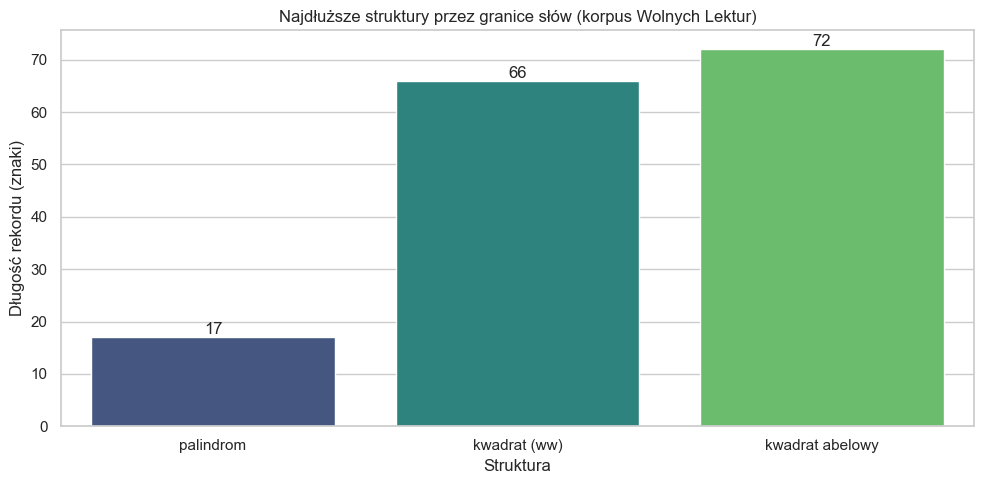

In [5]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=corpus_records_df, x="structure_label", y="length", hue="structure_label", palette="viridis", legend=False
)
ax.set_title("Najdłuższe struktury przez granice słów (korpus Wolnych Lektur)")
ax.set_xlabel("Struktura")
ax.set_ylabel("Długość rekordu (znaki)")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
save_fig("corpus_cross_boundary_records")
plt.show()

## 4. Dwuwyrazowe przetasowane kwadraty (4 języki)

Pojedyncze słowa rzadko są tangramami, więc dłuższe przetasowane kwadraty powstają dopiero ze
sklejenia **dwóch różnych słów** `w1 + w2`. Sklejenie jest tangramem tylko, gdy oba słowa mają tę
samą maskę parzystości liter — dlatego `two_word_shuffles` grupuje słowa w „kubełki parzystości"
i testuje wyłącznie pary w obrębie kubełka. Wynik: `two_word_df`.

In [6]:
two_word_results = {lang: two_word_shuffles(load_words(lang), max_length=2 * MAX_SHUFFLED_LEN) for lang in LANGUAGES}

two_word_rows = []
for lang in LANGUAGES:
    pairs = two_word_results[lang]
    record = pairs[0] if pairs else None
    non_anagram = sum(Counter(p.first) != Counter(p.second) for p in pairs)
    two_word_rows.append(
        {
            "language": lang,
            "language_label": LANGUAGE_LABELS[lang],
            "pairs": len(pairs),
            "record_length": record.length if record else 0,
            "record_example": record.text if record else "",
            "pct_non_anagram": round(100.0 * non_anagram / len(pairs), 1) if pairs else 0.0,
        }
    )
two_word_df = pd.DataFrame(two_word_rows)
display(two_word_df)

,language,language_label,pairs,record_length,record_example,pct_non_anagram
0,pl,polski,19510,38,dwudziestkadwójkadwudziestkachdwójkach,98.4
1,en,angielski,5895,26,statelessnesstastelessness,98.9
2,de,niemiecki,4297,40,zurückzutransportierenrücktransportieren,98.9
3,fr,francuski,21065,46,lieutenantegouverneurelieutenantesgouverneures,99.7


Liczba znalezionych par wg języka. Dane wejściowe: `two_word_df`.

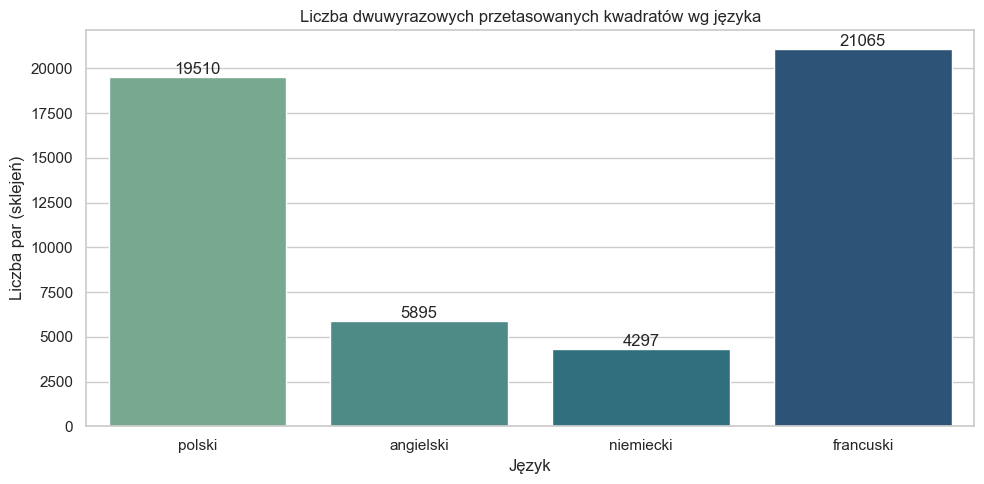

In [7]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=two_word_df, x="language_label", y="pairs", hue="language_label", palette="crest", legend=False)
ax.set_title("Liczba dwuwyrazowych przetasowanych kwadratów wg języka")
ax.set_xlabel("Język")
ax.set_ylabel("Liczba par (sklejeń)")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
save_fig("two_word_counts")
plt.show()

Długość najdłuższego sklejenia wg języka. Dane wejściowe: `two_word_df`.

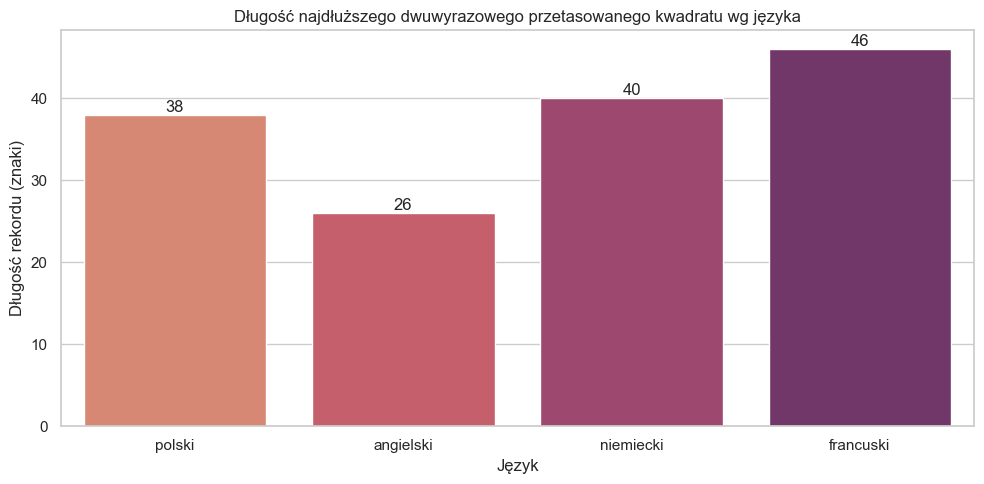

In [8]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=two_word_df, x="language_label", y="record_length", hue="language_label", palette="flare", legend=False
)
ax.set_title("Długość najdłuższego dwuwyrazowego przetasowanego kwadratu wg języka")
ax.set_xlabel("Język")
ax.set_ylabel("Długość rekordu (znaki)")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
save_fig("two_word_record_length")
plt.show()

Najdłuższe sklejenia oraz rozkład długości dla języka polskiego.

In [9]:
pl_pairs = two_word_results["pl"]
pl_top_df = pd.DataFrame(
    [{"first": p.first, "second": p.second, "concatenation": p.text, "length": p.length} for p in pl_pairs[:15]]
)
display(pl_top_df)

,first,second,concatenation,length
0,dwudziestkadwójka,dwudziestkachdwójkach,dwudziestkadwójkadwudziestkachdwójkach,38
1,dwudziestkadwójka,dwudziestkamidwójkami,dwudziestkadwójkadwudziestkamidwójkami,38
2,dwudziestkapiątka,dwudziestkachpiątkach,dwudziestkapiątkadwudziestkachpiątkach,38
3,dwudziestkapiątka,dwudziestkamipiątkami,dwudziestkapiątkadwudziestkamipiątkami,38
4,daimlerchrysler,daimlerowichryslerowi,daimlerchryslerdaimlerowichryslerowi,36
5,daimlerchrysler,daimleremchryslerem,daimlerchryslerdaimleremchryslerem,34
6,daimlerchrysler,daimlerzechryslerze,daimlerchryslerdaimlerzechryslerze,34
7,daimlerchrysler,daimlerachryslera,daimlerchryslerdaimlerachryslera,32
8,dniepropetrowsk,dniepropietrowski,dniepropetrowskdniepropietrowski,32
9,niedoprzędzonym,niedoprzędzionymi,niedoprzędzonymniedoprzędzionymi,32


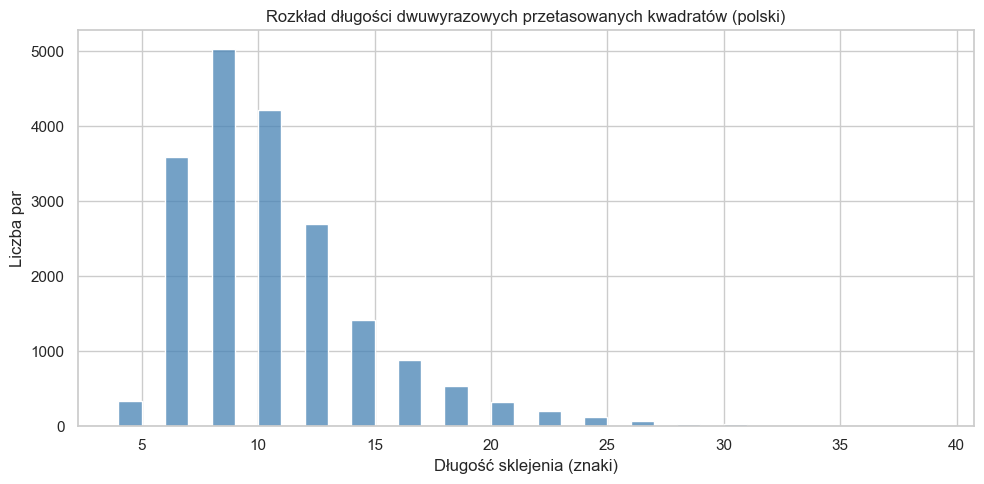

In [10]:
plt.figure(figsize=(10, 5))
pl_lengths = [p.length for p in pl_pairs]
ax = sns.histplot(pl_lengths, bins=range(min(pl_lengths), max(pl_lengths) + 2), color="steelblue")
ax.set_title("Rozkład długości dwuwyrazowych przetasowanych kwadratów (polski)")
ax.set_xlabel("Długość sklejenia (znaki)")
ax.set_ylabel("Liczba par")
plt.tight_layout()
save_fig("two_word_length_hist_pl")
plt.show()

## 5. Struktury w sekwencjach kolejnych słów (korpus)

Tu szukamy struktur w **kolejnych słowach realnego tekstu** — fragment jest więc gramatyczny z
definicji. Dla przetasowanych kwadratów daje to sensowne frazy oparte na paralelizmie (np. „X nie X,
Y nie Y"); domyślnie pomijamy literalne powtórzenia (`ww`). Dla kwadratów abelowych dostajemy
dłuższe układy lustrzane, a dla palindromów — frazy typu „kobyła ma mały bok". Wynik: `phrase_counts_df`.

In [11]:
corpus_sentences = []
for book in parse_wolne_lektury_file(BOOKS_PATH):
    for sentence in split_sentences(book.text):
        tokens = [token for token in (preprocessor.normalize(word) for word in sentence.split()) if token]
        if len(tokens) >= 2:
            corpus_sentences.append(tokens)

phrase_shuffle = phrase_shuffle_squares(corpus_sentences)
phrase_abelian = phrase_abelian_squares(corpus_sentences)
phrase_palindrome = phrase_palindromes(corpus_sentences)

phrase_counts_df = pd.DataFrame(
    [
        {
            "structure": "przetasowany kwadrat",
            "count": len(phrase_shuffle),
            "record_length": phrase_shuffle[0].length if phrase_shuffle else 0,
        },
        {
            "structure": "kwadrat abelowy",
            "count": len(phrase_abelian),
            "record_length": phrase_abelian[0].length if phrase_abelian else 0,
        },
        {
            "structure": "palindrom",
            "count": len(phrase_palindrome),
            "record_length": phrase_palindrome[0].length if phrase_palindrome else 0,
        },
    ]
)
display(phrase_counts_df)

,structure,count,record_length
0,przetasowany kwadrat,69,34
1,kwadrat abelowy,208,72
2,palindrom,97,10


Najdłuższe znalezione frazy każdego typu (sekwencje kolejnych słów z tekstu).

In [12]:
def phrase_table(matches, k=12):
    return pd.DataFrame([{"fraza": m.phrase, "długość": m.length, "liczba słów": len(m.tokens)} for m in matches[:k]])


print("Przetasowane kwadraty w kolejnych słowach:")
display(phrase_table(phrase_shuffle))
print("Kwadraty abelowe w kolejnych słowach:")
display(phrase_table(phrase_abelian))
print("Palindromy w kolejnych słowach:")
display(phrase_table(phrase_palindrome))

Przetasowane kwadraty w kolejnych słowach:


,fraza,długość,liczba słów
0,brat z bratem z przyjacielem przyjaciel,34,6
1,zgody lub niezgody humoru lub niehumoru,34,6
2,pogoda nie pogoda choroba nie choroba,32,6
3,wiatrak nie wiatrak wariat nie wariat,32,6
4,fuzje nie fuzje murzyny nie murzyny,30,6
5,kks koks koks brékeke kks brékeke,28,6
6,kwa kwa kiwiiiikiwiiiiii kra kra,28,5
7,cha cha cha cha kłaniam kłaniam,26,6
8,konie nie konie fuzje nie fuzje,26,6
9,witaj witaj charonie charonie,26,4


Kwadraty abelowe w kolejnych słowach:


,fraza,długość,liczba słów
0,mgła gęsta ptak czarny skrzydła białe boże białe skrzydła ptak czarny mgła gęsta boże,72,14
1,czy ja piękny a moja odpowiedź stosowna czy ja stosowny a moja odpowiedź piękna,66,14
2,boże bije serce cicho cicho boże cicho cicho serce bije boże boże,54,12
3,boże boże bije serce cicho cicho boże cicho cicho serce bije boże,54,12
4,bije serce cicho cicho boże cicho cicho serce bije boże,46,10
5,boże bije serce cicho cicho boże cicho cicho serce bije,46,10
6,będą dyndać jakem presler jakem presler będą dyndać,44,8
7,załzawione smutne serce serce smutne załzawione,42,6
8,od wschodu aż do zachodu od zachodu aż do wschodu,40,10
9,z salonu do przedpokoju z przedpokoju do salonu,40,8


Palindromy w kolejnych słowach:


,fraza,długość,liczba słów
0,zaraz zaraz,10,2
1,a to idiota,9,3
2,iii vi viii,9,3
3,jako lokaj,9,2
4,od do i od do,9,5
5,że toto też,9,3
6,a na pana,7,3
7,a zaraza,7,2
8,ani mi na,7,3
9,ani wina,7,2


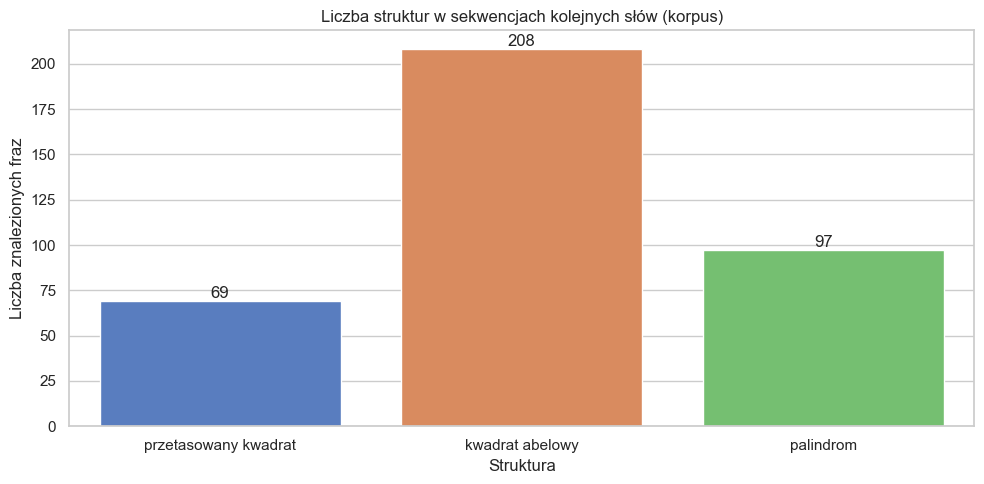

In [13]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=phrase_counts_df, x="structure", y="count", hue="structure", palette="muted", legend=False)
ax.set_title("Liczba struktur w sekwencjach kolejnych słów (korpus)")
ax.set_xlabel("Struktura")
ax.set_ylabel("Liczba znalezionych fraz")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
save_fig("phrase_structure_counts")
plt.show()

## 6. Podsumowanie

- **Pojedyncze słowa kontra sklejenia.** Niemiecki wygrywa struktury w pojedynczych słowach dzięki
  złożeniom (zob. `dictionaries.ipynb`), ale dwuwyrazowe przetasowane kwadraty są najdłuższe i
  najliczniejsze we francuskim (formy żeńsko/męskie i liczby mnogiej) — kubełki parzystości robią to
  w kilka sekund.
- **Przez granice słów >> w słowie.** Rekordy z korpusu (palindrom, kwadrat, kwadrat abelowy) są
  znacznie dłuższe niż wewnątrz pojedynczych słów, bo sklejają sąsiednie wyrazy.
- **Sens kontra długość.** Gramatyczny przetasowany kwadrat ma niski sufit (~34 znaki) — warunek
  tangramu sprawia, że dłuższe „sensowne" sklejenia to już tylko powtórzenia. Najdłuższe *sensowne*
  i niepowtórzeniowe sekwencje dają natomiast **kwadraty abelowe w kolejnych słowach** (~72 znaki).